We represent the steps as a nested list of steps. Each step consists of a metric + method, where the metric gives some diagnostic information and the method applies some kind of change to the dataset. Broadly, steps fall in either two categories: those that change the shape of the dataset, and those that change the distribution of the values within the dataset:

- Changing data shape (Filtering): mask features or samples
- Changing data distribution (Normalization/Batch Correction): move & rescale samples or features

Each step consists of a metric to answer a given question (e.g. computing data completeness, outliers, distributions, clustering) and a method that changes the data. For example, checking the metric data completeness and seeing that 12 % of features are less than 10 % complete across all samples could inform using a method for filtering for data completeness. Checking for completeness and removing incomplete features would then constitute one step in the analysis of a dataset. An ideal analysis would then be a sequence of steps, each of which consists of metric + method.

In [8]:
%load_ext autoreload
%autoreload 2

import alphapepttools as apt
import anndata as ad
import numpy as np
import pandas as pd

from msmetrics.datasets import wu2025
from msmetrics import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Load data

In [9]:
adata = ad.read_h5ad(wu2025())
adata

AnnData object with n_obs × n_vars = 2599 × 4279
    obs: 'ID', 'celltype', 'sample'

### 2. Log-transform (Preprocessing)

In [10]:
# Data is already log-transformed!
# adata_log = apt.pp.nanlog(adata, copy = True)

### 3. Visualize data completeness (QC-inspection)

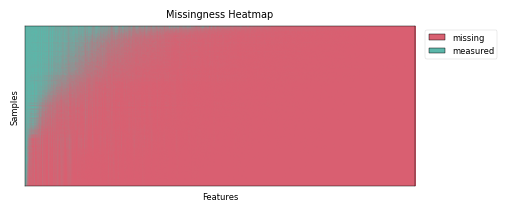

--> Dropping too incomplete features


INFO:root:pp.filter_data_completeness(): drop 3964 / 4279 features with >0.60 missing fraction.


--> Dropping too outlier samples
Removing 207 outlier samples: more than 3 MADs from the median


In [11]:
utils.draw_missingness(
    X=adata.X,
    xlabel="Features",
    ylabel="Samples",
    title="Missingness Heatmap",
)

# Flag features that are more than 60 % missing
print("--> Dropping too incomplete features", flush = True)
adata = apt.pp.filter_data_completeness(
    adata = adata,
    max_missing_fraction = 0.6,
    action = "drop",
)

# Compute actual completeness in features
apt.metrics.fraction_complete(
    adata=adata,
)

# Compute median intensity of features
adata.obs["median_intensity"] = np.nanmedian(adata.X, axis=1)

# Flag outliers based on median absolute deviation
adata.obs["outlier"] = utils.mad_outlier(adata.obs["fraction_complete"], n_mad=3, direction="down") | utils.mad_outlier(
    adata.obs["median_intensity"], n_mad=3, direction="both"
)

# Remove outliers
print("--> Dropping too outlier samples", flush = True)
print(f"Removing {adata.obs['outlier'].sum()} outlier samples: more than 3 MADs from the median", flush = True)
adata = adata[~adata.obs["outlier"]]

### 4. Normalization

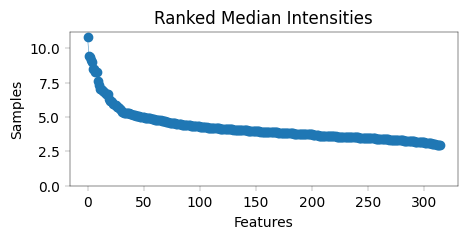

In [13]:
# Visualize the median ranked intensities
utils.draw_ranked_median_intensities(
    X=adata.X,
    xlabel="Features",
    ylabel="Samples",
    title="Ranked Median Intensities",
)

 ### 5. Imputation

### 6. Batch correction

### 7. Differential expression (out of scope)